# 07 — Redshift and Scale Ablations

Goal:
- Determine which redshift slices and k-scale regions drive parameter recoverability.
- Use the existing n=100 dataset and fixed train/test split.
- Train fast baseline models on feature subsets.

This notebook is diagnostic and interpretability-focused.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS = PROJECT_ROOT / "results"
FIGURES = PROJECT_ROOT / "figures"

for path in [DATA_PROCESSED, RESULTS, FIGURES]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression


In [3]:
DATA_TAG = "n2000_production"
RANDOM_SEED = 42

print("Data tag:", DATA_TAG)

Data tag: n2000_production


In [4]:
X_raw = np.load(DATA_PROCESSED / f"feature_matrix_{DATA_TAG}.npy")
y_raw = np.load(DATA_PROCESSED / f"target_matrix_{DATA_TAG}.npy")

feature_names_df = pd.read_csv(DATA_PROCESSED / f"feature_names_{DATA_TAG}.csv")
target_names_df = pd.read_csv(DATA_PROCESSED / f"target_names_{DATA_TAG}.csv")

feature_names = feature_names_df["feature_name"].tolist()
target_names = target_names_df["target_name"].tolist()

split_data = np.load(DATA_PROCESSED / f"split_indices_{DATA_TAG}.npz")
train_indices = split_data["train_indices"]
test_indices = split_data["test_indices"]

print("X_raw:", X_raw.shape)
print("y_raw:", y_raw.shape)
print("Targets:", target_names)
print("Train/test:", len(train_indices), len(test_indices))

X_raw: (2000, 57)
y_raw: (2000, 5)
Targets: ['zeta', 'log10_Tvir', 'R_mfp', 'log10_LX', 'sigma8']
Train/test: 1600 400


In [5]:
assert X_raw.shape == (2000, 57)
assert y_raw.shape == (2000, 5)

assert len(feature_names) == X_raw.shape[1]
assert len(target_names) == y_raw.shape[1]

assert np.all(np.isfinite(X_raw))
assert np.all(np.isfinite(y_raw))

print("Validation passed.")

Validation passed.


In [6]:
def parse_feature_name(name):
    """
    Expected format:
    delta2_z12.0_k0.08491
    """
    match = re.match(r"delta2_z([0-9.]+)_k([0-9.]+)", name)

    if match is None:
        raise ValueError(f"Could not parse feature name: {name}")

    z = float(match.group(1))
    k = float(match.group(2))

    return z, k


feature_meta_rows = []

for idx, name in enumerate(feature_names):
    z, k = parse_feature_name(name)

    feature_meta_rows.append({
        "feature_index": idx,
        "feature_name": name,
        "z": z,
        "k": k,
    })

feature_meta = pd.DataFrame(feature_meta_rows)

feature_meta.head()

,feature_index,feature_name,z,k
0,0,delta2_z12.0_k0.08491,12.0,0.08491
1,1,delta2_z12.0_k0.10379,12.0,0.10379
2,2,delta2_z12.0_k0.12686,12.0,0.12686
3,3,delta2_z12.0_k0.15507,12.0,0.15507
4,4,delta2_z12.0_k0.18954,12.0,0.18954


In [7]:
available_redshifts = sorted(feature_meta["z"].unique(), reverse=True)
available_k = sorted(feature_meta["k"].unique())

print("Available redshifts:", available_redshifts)
print("Number of k bins:", len(available_k))
print("k min/max:", min(available_k), max(available_k))

Available redshifts: [np.float64(12.0), np.float64(10.0), np.float64(8.0)]
Number of k bins: 19
k min/max: 0.08491 3.14991


In [8]:
k_values = np.array(available_k)

k_low_cut = np.percentile(k_values, 33.3)
k_high_cut = np.percentile(k_values, 66.7)

print("Low-k cutoff:", k_low_cut)
print("High-k cutoff:", k_high_cut)

def assign_k_group(k):
    if k <= k_low_cut:
        return "low_k"
    elif k <= k_high_cut:
        return "mid_k"
    else:
        return "high_k"

feature_meta["k_group"] = feature_meta["k"].apply(assign_k_group)

feature_meta.groupby("k_group").size()

Low-k cutoff: 0.28288093999999997
High-k cutoff: 0.9457198800000001


k_group
high_k    18
low_k     18
mid_k     21
dtype: int64

In [9]:
feature_groups = {}

# Full feature set
feature_groups["all_redshifts_all_k"] = feature_meta["feature_index"].to_numpy()

# Redshift-only groups
for z in available_redshifts:
    group_name = f"z_{z:.1f}_all_k"
    feature_groups[group_name] = feature_meta.loc[
        feature_meta["z"] == z,
        "feature_index"
    ].to_numpy()

# Scale-only groups
for k_group in ["low_k", "mid_k", "high_k"]:
    group_name = f"all_z_{k_group}"
    feature_groups[group_name] = feature_meta.loc[
        feature_meta["k_group"] == k_group,
        "feature_index"
    ].to_numpy()

# Redshift + scale groups
for z in available_redshifts:
    for k_group in ["low_k", "mid_k", "high_k"]:
        group_name = f"z_{z:.1f}_{k_group}"
        feature_groups[group_name] = feature_meta.loc[
            (feature_meta["z"] == z)
            & (feature_meta["k_group"] == k_group),
            "feature_index"
        ].to_numpy()

for name, indices in feature_groups.items():
    print(f"{name}: {len(indices)} features")

all_redshifts_all_k: 57 features
z_12.0_all_k: 19 features
z_10.0_all_k: 19 features
z_8.0_all_k: 19 features
all_z_low_k: 18 features
all_z_mid_k: 21 features
all_z_high_k: 18 features
z_12.0_low_k: 6 features
z_12.0_mid_k: 7 features
z_12.0_high_k: 6 features
z_10.0_low_k: 6 features
z_10.0_mid_k: 7 features
z_10.0_high_k: 6 features
z_8.0_low_k: 6 features
z_8.0_mid_k: 7 features
z_8.0_high_k: 6 features


In [10]:
def evaluate_multioutput(y_true, y_pred, target_names, model_name, group_name, n_features):
    rows = []

    for i, target in enumerate(target_names):
        rows.append({
            "model": model_name,
            "feature_group": group_name,
            "n_features": n_features,
            "target": target,
            "r2": r2_score(y_true[:, i], y_pred[:, i]),
            "mae": mean_absolute_error(y_true[:, i], y_pred[:, i]),
        })

    return rows

In [11]:
ablation_rows = []

for group_name, feature_idx in feature_groups.items():

    print("=" * 70)
    print("Feature group:", group_name)
    print("Number of features:", len(feature_idx))
    print("=" * 70)

    X_group = X_raw[:, feature_idx]

    X_train_raw = X_group[train_indices]
    X_test_raw = X_group[test_indices]

    y_train = y_raw[train_indices]
    y_test = y_raw[test_indices]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    rows = evaluate_multioutput(
        y_true=y_test,
        y_pred=y_pred,
        target_names=target_names,
        model_name="Random Forest",
        group_name=group_name,
        n_features=len(feature_idx),
    )

    ablation_rows.extend(rows)

print("Ablation runs complete.")

Feature group: all_redshifts_all_k
Number of features: 57
Feature group: z_12.0_all_k
Number of features: 19
Feature group: z_10.0_all_k
Number of features: 19
Feature group: z_8.0_all_k
Number of features: 19
Feature group: all_z_low_k
Number of features: 18
Feature group: all_z_mid_k
Number of features: 21
Feature group: all_z_high_k
Number of features: 18
Feature group: z_12.0_low_k
Number of features: 6
Feature group: z_12.0_mid_k
Number of features: 7
Feature group: z_12.0_high_k
Number of features: 6
Feature group: z_10.0_low_k
Number of features: 6
Feature group: z_10.0_mid_k
Number of features: 7
Feature group: z_10.0_high_k
Number of features: 6
Feature group: z_8.0_low_k
Number of features: 6
Feature group: z_8.0_mid_k
Number of features: 7
Feature group: z_8.0_high_k
Number of features: 6
Ablation runs complete.


In [12]:
ablation_results = pd.DataFrame(ablation_rows)

ablation_results.head()

,model,feature_group,n_features,target,r2,mae
0,Random Forest,all_redshifts_all_k,57,zeta,-0.045363,18.117262
1,Random Forest,all_redshifts_all_k,57,log10_Tvir,-0.011870,0.377053
2,Random Forest,all_redshifts_all_k,57,R_mfp,0.541309,4.122118
3,Random Forest,all_redshifts_all_k,57,log10_LX,-0.014741,0.998536
4,Random Forest,all_redshifts_all_k,57,sigma8,0.958091,0.006876


In [13]:
ablation_results_path = RESULTS / f"redshift_scale_ablation_results_{DATA_TAG}.csv"

ablation_results.to_csv(ablation_results_path, index=False)

print("Saved ablation results to:", ablation_results_path)

Saved ablation results to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/redshift_scale_ablation_results_n2000_production.csv


In [14]:
redshift_group_names = [f"z_{z:.1f}_all_k" for z in available_redshifts]

redshift_results = ablation_results[
    ablation_results["feature_group"].isin(redshift_group_names)
].copy()

redshift_heatmap = redshift_results.pivot_table(
    index="target",
    columns="feature_group",
    values="r2",
)

redshift_heatmap = redshift_heatmap[redshift_group_names]

redshift_heatmap

feature_group,z_12.0_all_k,z_10.0_all_k,z_8.0_all_k
target,,,
R_mfp,-0.003123,-0.004013,0.521346
log10_LX,-0.025957,-0.026269,-0.018170
log10_Tvir,0.003208,-0.001675,-0.020119
sigma8,0.964148,0.982304,0.878038
zeta,-0.024003,-0.044452,-0.065806


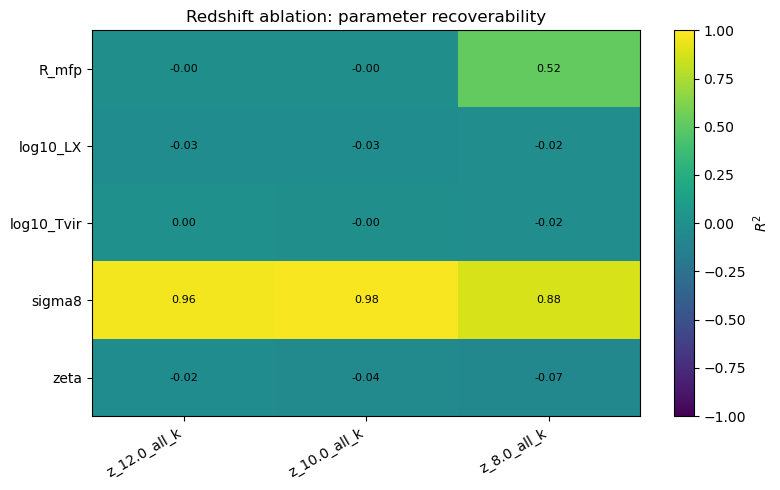

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/redshift_ablation_heatmap_n2000_production.png


In [15]:
plt.figure(figsize=(8, 5))

im = plt.imshow(redshift_heatmap.values, aspect="auto", vmin=-1, vmax=1)

plt.xticks(
    ticks=np.arange(len(redshift_heatmap.columns)),
    labels=redshift_heatmap.columns,
    rotation=30,
    ha="right",
)

plt.yticks(
    ticks=np.arange(len(redshift_heatmap.index)),
    labels=redshift_heatmap.index,
)

plt.colorbar(im, label=r"$R^2$")

for i in range(redshift_heatmap.shape[0]):
    for j in range(redshift_heatmap.shape[1]):
        plt.text(
            j,
            i,
            f"{redshift_heatmap.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

plt.title("Redshift ablation: parameter recoverability")
plt.tight_layout()

redshift_heatmap_path = FIGURES / f"redshift_ablation_heatmap_{DATA_TAG}.png"
plt.savefig(redshift_heatmap_path, dpi=300)
plt.show()

print("Saved figure to:", redshift_heatmap_path)

In [16]:
scale_group_names = ["all_z_low_k", "all_z_mid_k", "all_z_high_k"]

scale_results = ablation_results[
    ablation_results["feature_group"].isin(scale_group_names)
].copy()

scale_heatmap = scale_results.pivot_table(
    index="target",
    columns="feature_group",
    values="r2",
)

scale_heatmap = scale_heatmap[scale_group_names]

scale_heatmap

feature_group,all_z_low_k,all_z_mid_k,all_z_high_k
target,,,
R_mfp,0.444492,0.480759,0.529593
log10_LX,-0.013016,-0.028364,-0.038911
log10_Tvir,-0.011857,-0.012229,-0.006910
sigma8,0.868797,0.967865,0.986364
zeta,-0.045454,-0.066071,-0.073399


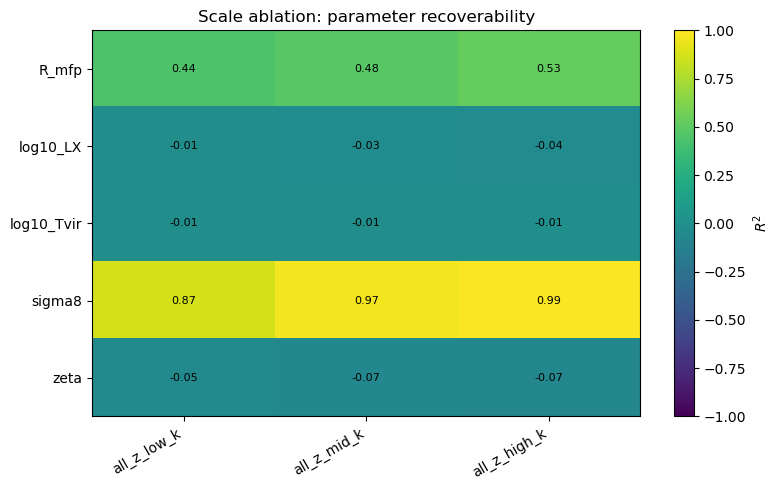

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/scale_ablation_heatmap_n2000_production.png


In [17]:
plt.figure(figsize=(8, 5))

im = plt.imshow(scale_heatmap.values, aspect="auto", vmin=-1, vmax=1)

plt.xticks(
    ticks=np.arange(len(scale_heatmap.columns)),
    labels=scale_heatmap.columns,
    rotation=30,
    ha="right",
)

plt.yticks(
    ticks=np.arange(len(scale_heatmap.index)),
    labels=scale_heatmap.index,
)

plt.colorbar(im, label=r"$R^2$")

for i in range(scale_heatmap.shape[0]):
    for j in range(scale_heatmap.shape[1]):
        plt.text(
            j,
            i,
            f"{scale_heatmap.values[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

plt.title("Scale ablation: parameter recoverability")
plt.tight_layout()

scale_heatmap_path = FIGURES / f"scale_ablation_heatmap_{DATA_TAG}.png"
plt.savefig(scale_heatmap_path, dpi=300)
plt.show()

print("Saved figure to:", scale_heatmap_path)

In [18]:
combined_groups = [
    name for name in feature_groups.keys()
    if name.startswith("z_") and (
        name.endswith("low_k")
        or name.endswith("mid_k")
        or name.endswith("high_k")
    )
]

combined_results = ablation_results[
    ablation_results["feature_group"].isin(combined_groups)
].copy()

combined_results.head()

,model,feature_group,n_features,target,r2,mae
35,Random Forest,z_12.0_low_k,6,zeta,-0.033381,18.040391
36,Random Forest,z_12.0_low_k,6,log10_Tvir,-0.012174,0.379038
37,Random Forest,z_12.0_low_k,6,R_mfp,-0.011334,6.363318
38,Random Forest,z_12.0_low_k,6,log10_LX,-0.021283,1.004696
39,Random Forest,z_12.0_low_k,6,sigma8,0.494577,0.024873


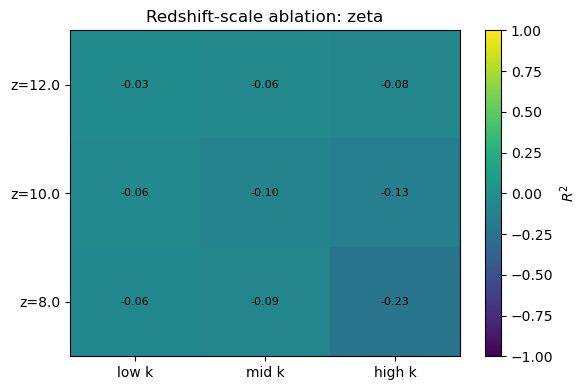

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/redshift_scale_ablation_zeta_n2000_production.png


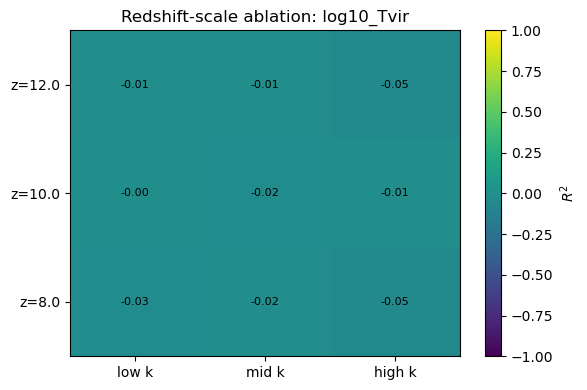

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/redshift_scale_ablation_log10_Tvir_n2000_production.png


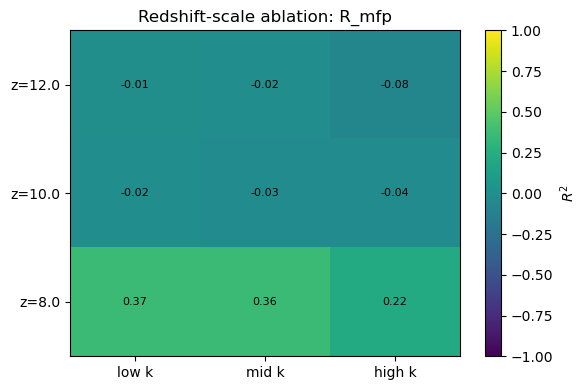

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/redshift_scale_ablation_R_mfp_n2000_production.png


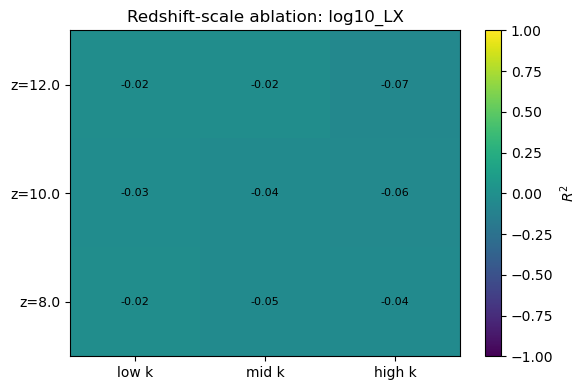

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/redshift_scale_ablation_log10_LX_n2000_production.png


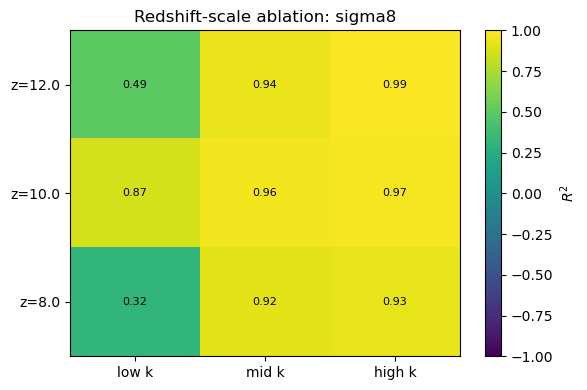

Saved: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/redshift_scale_ablation_sigma8_n2000_production.png


In [19]:
combined_heatmap_paths = []

for target in target_names:

    target_df = combined_results[combined_results["target"] == target].copy()

    matrix = np.zeros((len(available_redshifts), 3))
    matrix[:] = np.nan

    for i, z in enumerate(available_redshifts):
        for j, k_group in enumerate(["low_k", "mid_k", "high_k"]):
            group_name = f"z_{z:.1f}_{k_group}"

            value = target_df.loc[
                target_df["feature_group"] == group_name,
                "r2"
            ].values

            if len(value) > 0:
                matrix[i, j] = value[0]

    plt.figure(figsize=(6, 4))

    im = plt.imshow(matrix, aspect="auto", vmin=-1, vmax=1)

    plt.xticks(
        ticks=np.arange(3),
        labels=["low k", "mid k", "high k"]
    )

    plt.yticks(
        ticks=np.arange(len(available_redshifts)),
        labels=[f"z={z:.1f}" for z in available_redshifts]
    )

    plt.colorbar(im, label=r"$R^2$")

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            plt.text(
                j,
                i,
                f"{matrix[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

    plt.title(f"Redshift-scale ablation: {target}")
    plt.tight_layout()

    out_path = FIGURES / f"redshift_scale_ablation_{target}_{DATA_TAG}.png"
    plt.savefig(out_path, dpi=300)
    plt.show()

    combined_heatmap_paths.append(out_path)

    print("Saved:", out_path)

In [20]:
full_results = ablation_results[
    ablation_results["feature_group"] == "all_redshifts_all_k"
].copy()

best_ablation = (
    ablation_results
    .sort_values("r2", ascending=False)
    .groupby("target")
    .head(1)
    .sort_values("r2", ascending=False)
)

comparison_rows = []

for target in target_names:
    full_r2 = full_results.loc[
        full_results["target"] == target,
        "r2"
    ].values[0]

    best_row = best_ablation[best_ablation["target"] == target].iloc[0]

    comparison_rows.append({
        "target": target,
        "full_feature_r2": full_r2,
        "best_ablation_group": best_row["feature_group"],
        "best_ablation_r2": best_row["r2"],
        "delta_best_minus_full": best_row["r2"] - full_r2,
    })

ablation_summary = pd.DataFrame(comparison_rows)

ablation_summary

,target,full_feature_r2,best_ablation_group,best_ablation_r2,delta_best_minus_full
0,zeta,-0.045363,z_12.0_all_k,-0.024003,0.021360
1,log10_Tvir,-0.011870,z_12.0_all_k,0.003208,0.015078
2,R_mfp,0.541309,all_redshifts_all_k,0.541309,0.000000
3,log10_LX,-0.014741,all_z_low_k,-0.013016,0.001725
4,sigma8,0.958091,z_12.0_high_k,0.986736,0.028646


In [21]:
ablation_summary_path = RESULTS / f"redshift_scale_ablation_summary_{DATA_TAG}.csv"

ablation_summary.to_csv(ablation_summary_path, index=False)

print("Saved ablation summary to:", ablation_summary_path)

Saved ablation summary to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/redshift_scale_ablation_summary_n2000_production.csv


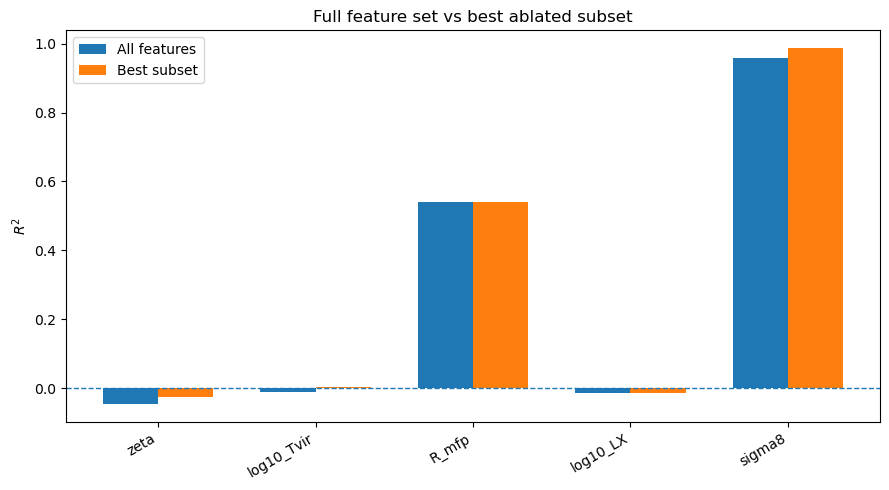

Saved figure to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/figures/full_vs_best_ablation_n2000_production.png


In [22]:
plt.figure(figsize=(9, 5))

x = np.arange(len(target_names))
width = 0.35

ordered_summary = ablation_summary.set_index("target").loc[target_names].reset_index()

plt.bar(
    x - width / 2,
    ordered_summary["full_feature_r2"],
    width=width,
    label="All features",
)

plt.bar(
    x + width / 2,
    ordered_summary["best_ablation_r2"],
    width=width,
    label="Best subset",
)

plt.axhline(0.0, linestyle="--", linewidth=1)

plt.xticks(x, target_names, rotation=30, ha="right")
plt.ylabel(r"$R^2$")
plt.title("Full feature set vs best ablated subset")
plt.legend()
plt.tight_layout()

full_vs_best_path = FIGURES / f"full_vs_best_ablation_{DATA_TAG}.png"
plt.savefig(full_vs_best_path, dpi=300)
plt.show()

print("Saved figure to:", full_vs_best_path)

In [23]:
ablation_metadata = {
    "notebook": "07_redshift_scale_ablations.ipynb",
    "data_tag": DATA_TAG,
    "model": "RandomForestRegressor",
    "n_samples": int(X_raw.shape[0]),
    "n_features_total": int(X_raw.shape[1]),
    "n_targets": int(y_raw.shape[1]),
    "target_names": target_names,
    "available_redshifts": available_redshifts,
    "k_min": float(min(available_k)),
    "k_max": float(max(available_k)),
    "k_low_cut": float(k_low_cut),
    "k_high_cut": float(k_high_cut),
    "feature_groups": {
        name: len(indices) for name, indices in feature_groups.items()
    },
    "notes": (
        "Ablation analysis uses the fixed train/test split from Notebook 04. "
        "Results from n=100 are exploratory and should be interpreted as "
        "diagnostics of information localization, not final performance claims."
    ),
}

ablation_metadata_path = RESULTS / f"redshift_scale_ablation_metadata_{DATA_TAG}.json"

with open(ablation_metadata_path, "w") as f:
    json.dump(ablation_metadata, f, indent=2)

print("Saved metadata to:", ablation_metadata_path)

Saved metadata to: /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/redshift_scale_ablation_metadata_n2000_production.json


In [24]:
print("=" * 60)
print("Notebook 07 completed successfully.")
print("=" * 60)

print("Dataset tag:", DATA_TAG)
print("Feature groups evaluated:", len(feature_groups))
print("Total ablation rows:", len(ablation_results))

print("\nAblation summary:")
print(ablation_summary)

print("\nSaved files:")
print(" -", ablation_results_path)
print(" -", ablation_summary_path)
print(" -", redshift_heatmap_path)
print(" -", scale_heatmap_path)
print(" -", full_vs_best_path)
print(" -", ablation_metadata_path)

print("\nCombined heatmaps:")
for path in combined_heatmap_paths:
    print(" -", path)

Notebook 07 completed successfully.
Dataset tag: n2000_production
Feature groups evaluated: 16
Total ablation rows: 80

Ablation summary:
       target  full_feature_r2  best_ablation_group  best_ablation_r2  \
0        zeta        -0.045363         z_12.0_all_k         -0.024003   
1  log10_Tvir        -0.011870         z_12.0_all_k          0.003208   
2       R_mfp         0.541309  all_redshifts_all_k          0.541309   
3    log10_LX        -0.014741          all_z_low_k         -0.013016   
4      sigma8         0.958091        z_12.0_high_k          0.986736   

   delta_best_minus_full  
0               0.021360  
1               0.015078  
2               0.000000  
3               0.001725  
4               0.028646  

Saved files:
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/redshift_scale_ablation_results_n2000_production.csv
 - /Users/rudhresh/Desktop/Research/21cm_symbolic_regression/results/redshift_scale_ablation_summary_n2000_production.csv
 - 